Titanic - Survivability
Data : Kaggle Titanic Dataset(891 Passengers)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('train.csv')

In [3]:
df = df.drop(columns=['Cabin'])

In [4]:
df['Age'] = df['Age'].fillna(df.Age.median())

In [5]:
df.Embarked = df.Embarked.fillna(df.Embarked.mode()[0])

In [6]:
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [7]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [8]:
df.groupby('Sex')['Survived'].mean()


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [9]:
df.groupby(['Pclass','Sex'])['Survived'].mean()


Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [10]:
df['Age_Group'] = pd.cut(df.Age, bins=[0,12,18,35,60,100],labels=['Child','Teenager','Adult','Old_Adult','Senior'])
df.groupby('Age_Group')['Survived'].mean()


Age_Group
Child        0.579710
Teenager     0.428571
Adult        0.353271
Old_Adult    0.400000
Senior       0.227273
Name: Survived, dtype: float64

In [11]:
df.groupby(['Pclass','Sex','Age_Group'])['Survived'].mean()

Pclass  Sex     Age_Group
1       female  Child        0.000000
                Teenager     1.000000
                Adult        0.977778
                Old_Adult    0.972222
                Senior       1.000000
        male    Child        1.000000
                Teenager     0.500000
                Adult        0.392157
                Old_Adult    0.370370
                Senior       0.083333
2       female  Child        1.000000
                Teenager     1.000000
                Adult        0.928571
                Old_Adult    0.850000
        male    Child        1.000000
                Teenager     0.000000
                Adult        0.095238
                Old_Adult    0.037037
                Senior       0.333333
3       female  Child        0.478261
                Teenager     0.550000
                Adult        0.546512
                Old_Adult    0.142857
                Senior       1.000000
        male    Child        0.360000
                Teenager

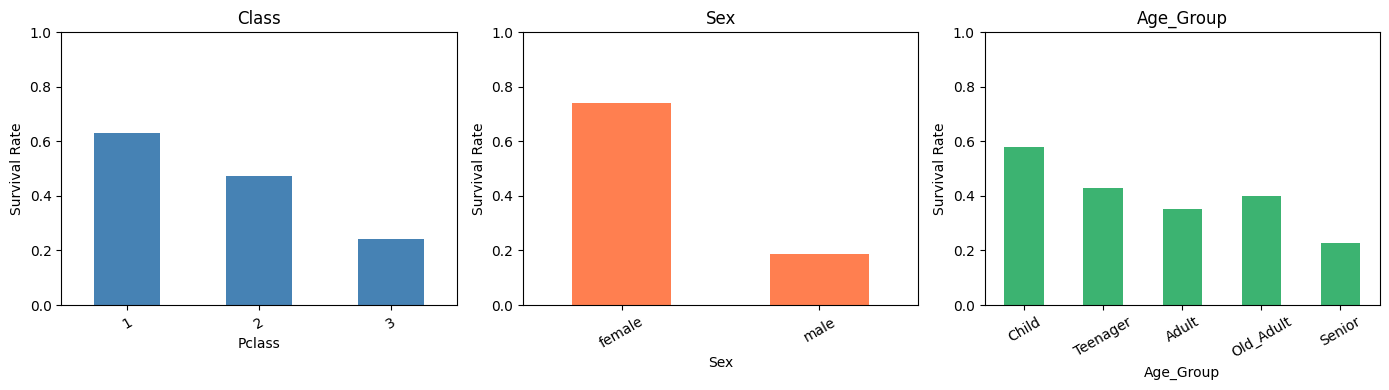

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: nach Klasse
df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[0], title='Class', color='steelblue'
)

# Plot 2: nach Geschlecht
df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[1], title='Sex', color='coral'
)

# Plot 3: nach Altersgruppe
df.groupby('Age_Group')['Survived'].mean().plot(
    kind='bar', ax=axes[2], title='Age_Group', color='mediumseagreen'
)

for ax in axes:
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()